In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



monthly = pd.read_csv('../data/monthly_amortization_dimensional.csv')
daily_gross = pd.read_csv('../data/daily_gross_amount_and_members.csv')
daily_amort = pd.read_csv('../data/daily_amortization_tm1.csv')


daily_gross['date'] = pd.to_datetime(daily_gross['date'])
daily_amort['date'] = pd.to_datetime(daily_amort['date'])
monthly['year_month'] = pd.to_datetime(monthly['year_month'])

print("Monthly shape:", monthly.shape)
print("Daily Gross shape:", daily_gross.shape)
print("Daily Amort shape:", daily_amort.shape)

print("\n Locations:", daily_gross['location'].unique().tolist())
print(" Products:", daily_gross['membership_product'].unique().tolist())
print("Date range:", daily_gross['date'].min(), "to", daily_gross['date'].max())

Monthly shape: (1758, 9)
Daily Gross shape: (10504, 9)
Daily Amort shape: (50280, 9)

 Locations: ['AHP', 'JAP', 'JWM', 'DCP']
 Products: ['1 MONTH', '3 MONTH', '2 MONTH', '12 MONTH', '6 MONTH']
Date range: 2021-04-08 00:00:00 to 2026-01-18 00:00:00


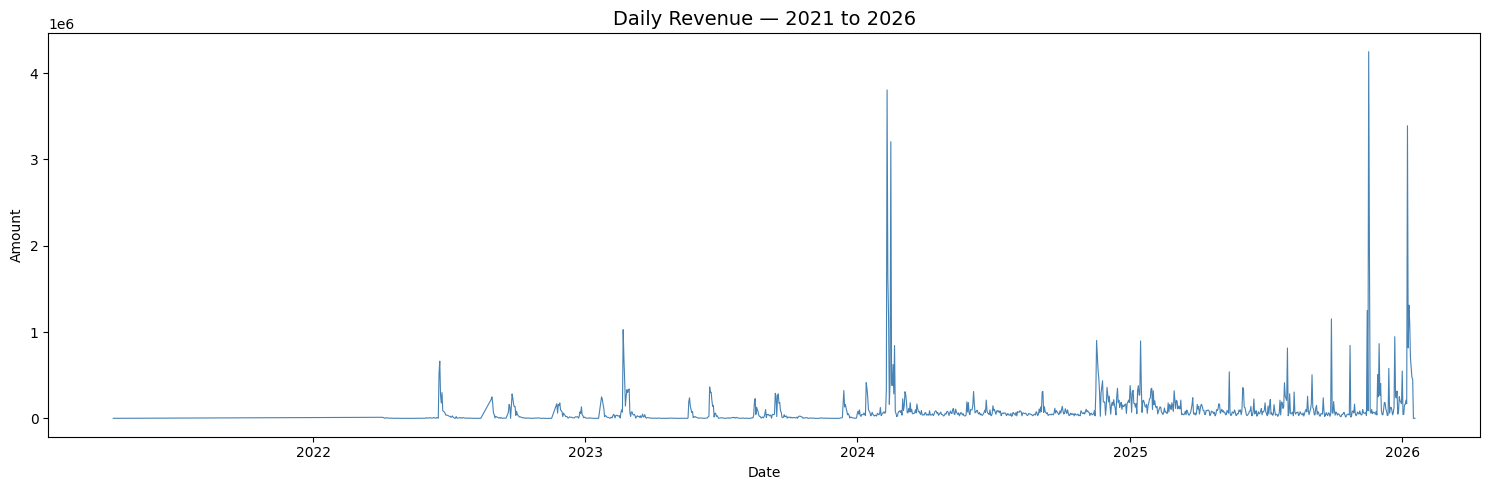

Total Revenue: 128,135,570
Average Daily Revenue: 100,106


In [19]:

daily_revenue = daily_gross.groupby('date')['gross_amount'].sum().reset_index()

plt.figure(figsize=(15, 5))
plt.plot(daily_revenue['date'], daily_revenue['gross_amount'], color='steelblue', linewidth=0.8)
plt.title('Daily Revenue — 2021 to 2026', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Amount')
plt.tight_layout()
plt.show()

print("Total Revenue:", f"{daily_gross['gross_amount'].sum():,.0f}")
print("Average Daily Revenue:", f"{daily_revenue['gross_amount'].mean():,.0f}")

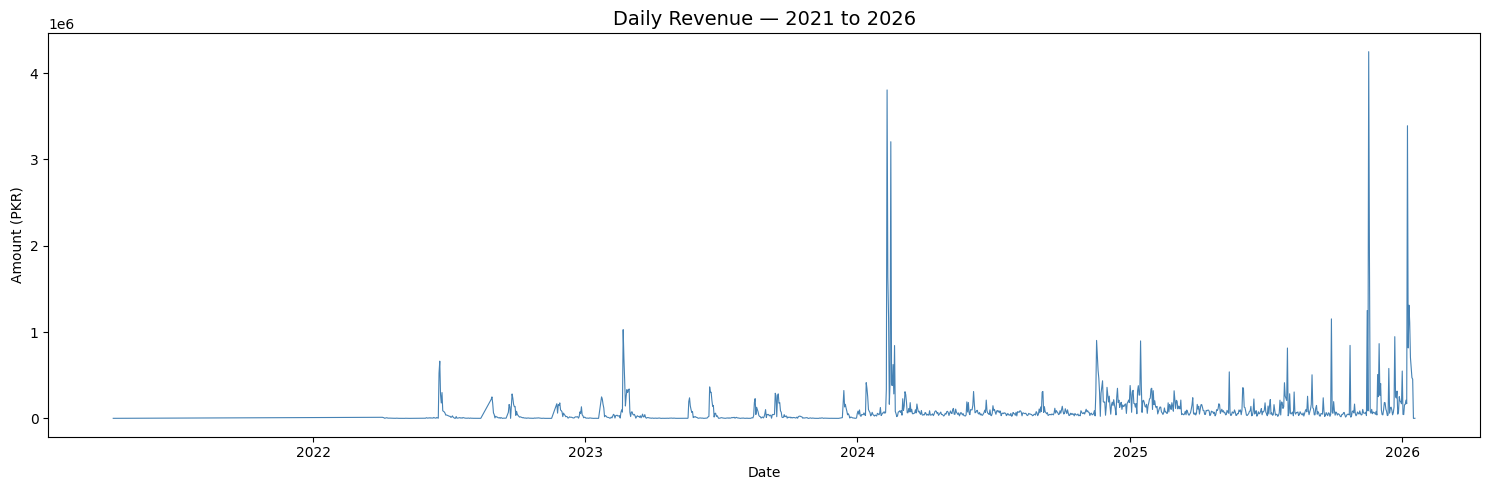

Total Revenue: 128,135,570
Average Daily Revenue: 100,106


In [20]:
daily_revenue = daily_gross.groupby('date')['gross_amount'].sum().reset_index()

plt.figure(figsize=(15, 5))
plt.plot(daily_revenue['date'], daily_revenue['gross_amount'], color='steelblue', linewidth=0.8)
plt.title('Daily Revenue — 2021 to 2026', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Amount (PKR)')
plt.tight_layout()
plt.show()

print("Total Revenue:", f"{daily_gross['gross_amount'].sum():,.0f}")
print("Average Daily Revenue:", f"{daily_revenue['gross_amount'].mean():,.0f}")

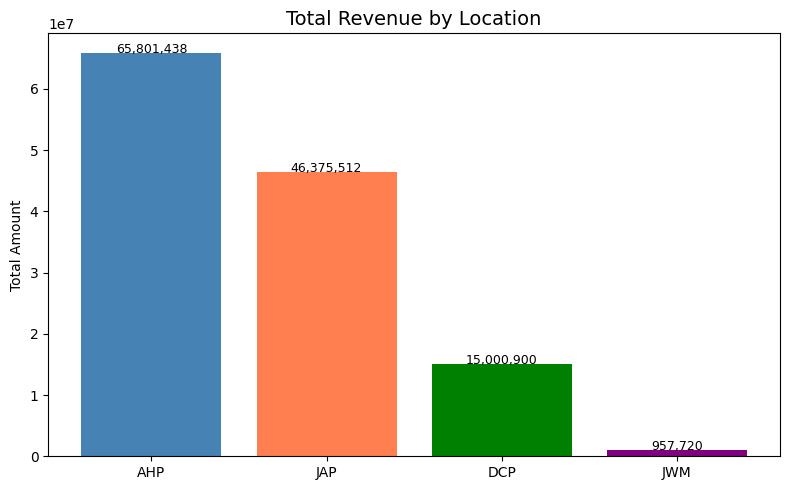

In [21]:
location_rev = daily_gross.groupby('location')['gross_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(location_rev.index, location_rev.values, color=['steelblue','coral','green','purple'])
for bar, val in zip(bars, location_rev.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10000,
             f'{val:,.0f}', ha='center', fontsize=9)

plt.title('Total Revenue by Location', fontsize=14)
plt.ylabel('Total Amount')
plt.tight_layout()
plt.show()

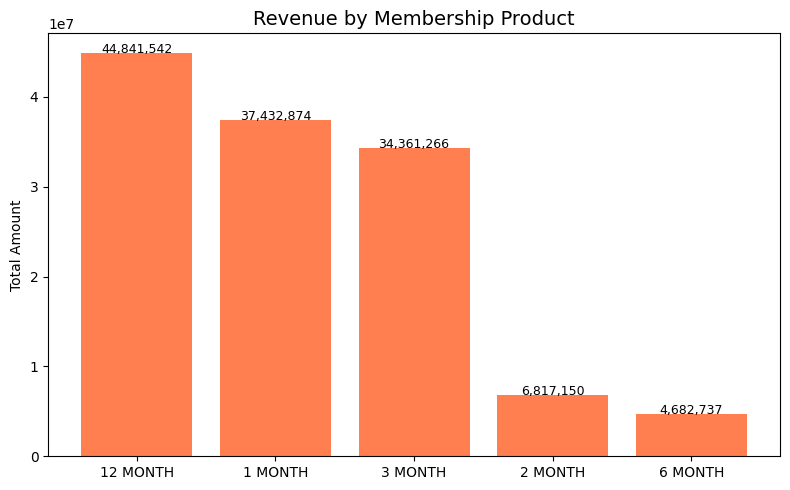

In [22]:
product_rev = daily_gross.groupby('membership_product')['gross_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(product_rev.index, product_rev.values, color='coral')
for bar, val in zip(bars, product_rev.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'{val:,.0f}', ha='center', fontsize=9)

plt.title('Revenue by Membership Product', fontsize=14)
plt.ylabel('Total Amount')
plt.tight_layout()
plt.show()

In [23]:
from prophet import Prophet

paid_daily = daily_gross[daily_gross['payment_status'] == 'PAID'].copy()

prophet_df = paid_daily.groupby('date')['gross_amount'].sum().reset_index()
prophet_df.columns = ['ds', 'y']

prophet_df = prophet_df[prophet_df['ds'] <= '2026-01-18']

print("Prophet data shape:", prophet_df.shape)
print("Date range:", prophet_df['ds'].min(), "to", prophet_df['ds'].max())
print("Sample:")
print(prophet_df.tail())

Prophet data shape: (1279, 2)
Date range: 2021-04-08 00:00:00 to 2026-01-18 00:00:00
Sample:
             ds          y
1274 2026-01-12  704133.17
1275 2026-01-13  578931.85
1276 2026-01-14  471461.46
1277 2026-01-15  454623.38
1278 2026-01-18    1200.00


In [25]:

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative' 
)

model.fit(prophet_df)

future = model.make_future_dataframe(periods=365)

forecast = model.predict(future)

print(" Model trained!")
print("Forecast shape:", forecast.shape)
print("\nNext 7 days forecast")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(370).head(7))

19:45:55 - cmdstanpy - INFO - Chain [1] start processing
19:45:55 - cmdstanpy - INFO - Chain [1] done processing


 Model trained!
Forecast shape: (1644, 19)

Next 7 days forecast
             ds           yhat     yhat_lower     yhat_upper
1274 2026-01-12  706726.416655  426266.891408  993873.369141
1275 2026-01-13  562627.728810  283114.165584  854645.214289
1276 2026-01-14  495613.386551  191855.743403  806087.841363
1277 2026-01-15  639955.744136  365788.878494  936804.612322
1278 2026-01-18  505455.997885  198586.149148  797935.992163
1279 2026-01-19  603700.088846  312078.145294  889778.577518
1280 2026-01-20  463750.509444  166028.517186  766688.412489


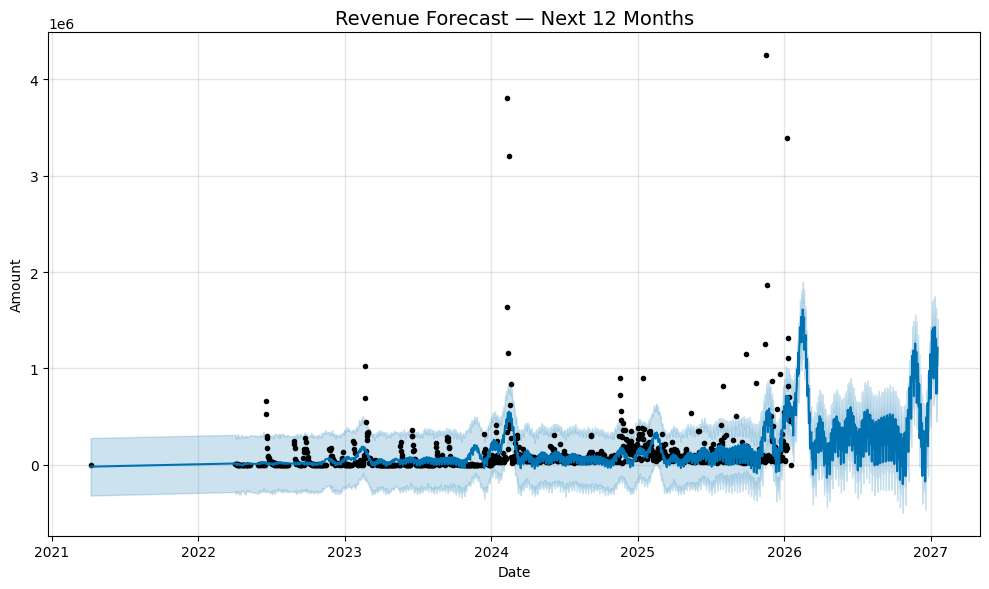

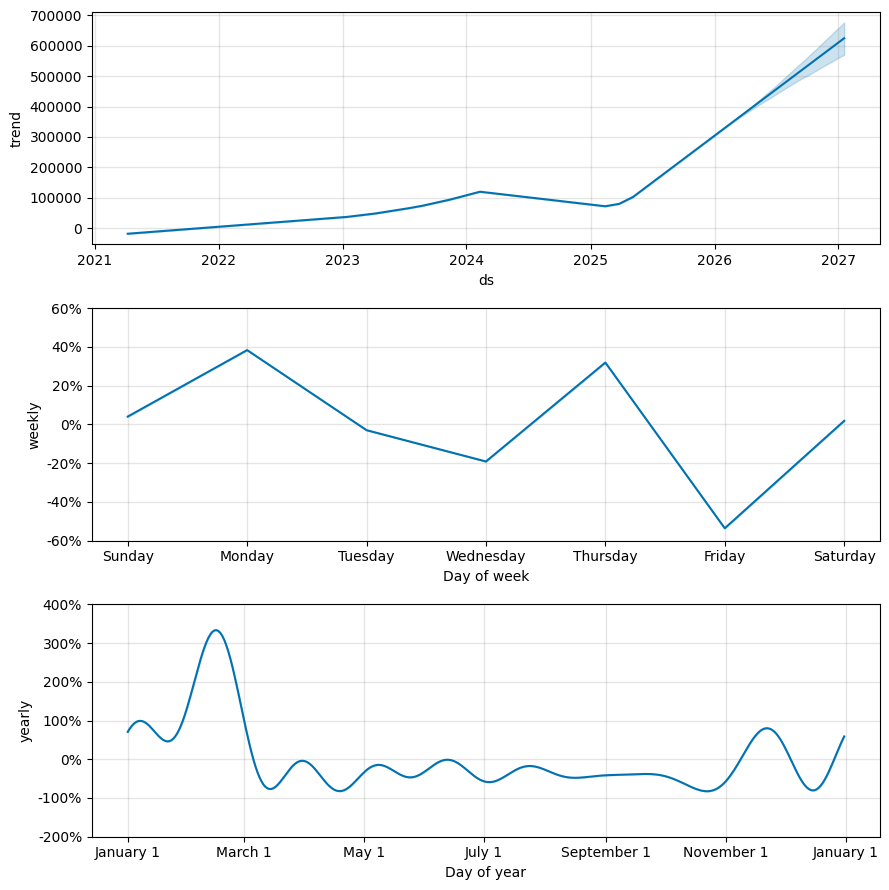

In [27]:
fig1 = model.plot(forecast)
plt.title('Revenue Forecast — Next 12 Months', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Amount')
plt.tight_layout()
plt.show()

fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.show()

In [29]:
forecast_future = forecast[forecast['ds'] > '2026-01-18'][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()

forecast_future['month'] = forecast_future['ds'].dt.to_period('M')
monthly_forecast = forecast_future.groupby('month').agg({
    'yhat': 'sum',
    'yhat_lower': 'sum', 
    'yhat_upper': 'sum'
}).reset_index()

monthly_forecast.columns = ['Month', 'Forecast', 'Low_Case', 'High_Case']
monthly_forecast['Forecast'] = monthly_forecast['Forecast'].clip(lower=0)
monthly_forecast['Low_Case'] = monthly_forecast['Low_Case'].clip(lower=0)

print(" Next 12 Months Revenue Forecast:")
print("="*60)
for _, row in monthly_forecast.head(12).iterrows():
    print(f"{row['Month']} | Forecast: {row['Forecast']:>12,.0f} | "
          f"Low: {row['Low_Case']:>12,.0f} | "
          f"High: {row['High_Case']:>12,.0f}")

 Next 12 Months Revenue Forecast:
2026-01 | Forecast:    7,128,294 | Low:    3,359,926 | High:   10,946,417
2026-02 | Forecast:   34,013,043 | Low:   25,873,318 | High:   42,124,572
2026-03 | Forecast:    8,668,761 | Low:            0 | High:   17,500,813
2026-04 | Forecast:    5,572,663 | Low:            0 | High:   14,156,346
2026-05 | Forecast:    8,695,428 | Low:            0 | High:   17,639,071
2026-06 | Forecast:   10,683,284 | Low:    1,959,379 | High:   19,308,897
2026-07 | Forecast:    9,159,406 | Low:      278,065 | High:   18,201,289
2026-08 | Forecast:    9,058,560 | Low:      117,571 | High:   17,967,391
2026-09 | Forecast:    9,325,637 | Low:      641,239 | High:   18,037,407
2026-10 | Forecast:    5,402,615 | Low:            0 | High:   14,436,609
2026-11 | Forecast:   22,962,624 | Low:   14,136,234 | High:   31,853,270
2026-12 | Forecast:   13,221,580 | Low:    4,184,987 | High:   22,184,004
